# 04_11 Clustering - GaussianMixture
Train and evaluate GaussianMixture.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train GaussianMixture va quan sat phan bo cluster cho phan khuc khach hang.
- Muc tieu ky thuat: Hien thi metric va bieu do cluster size ro rang tren notebook.

26/03/31 22:26:28 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:26:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 22:26:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:26:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:26:29 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


26/03/31 22:26:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/31 22:26:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


26/03/31 22:26:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


{'model_family': 'clustering', 'model_name': 'GaussianMixture', 'silhouette': 0.3107152616022038, 'rows': 96096, 'k': 6}


,model_family,model_name,silhouette,rows,k
0,clustering,GaussianMixture,0.310715,96096,6


,prediction,count
0,0,15997
1,2,16806
2,5,63293


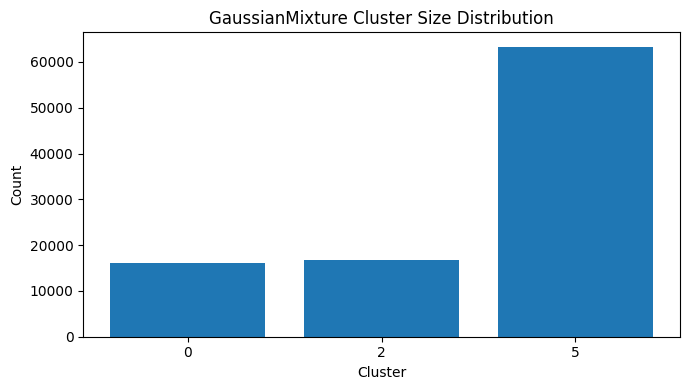

132

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pyspark.sql import SparkSession
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
spark=(SparkSession.builder.appName('04_11_gmm').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'clustering'/'gaussian_mixture'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
df=spark.read.parquet(str(FEATURE_DIR/'clustering_fe')).select('customer_unique_id','features').dropna()
gmm=GaussianMixture(featuresCol='features',predictionCol='prediction',k=6,maxIter=50,seed=42)
m=gmm.fit(df)
pred=m.transform(df)
sil=ClusteringEvaluator(featuresCol='features',predictionCol='prediction',metricName='silhouette').evaluate(pred)
metrics={'model_family':'clustering','model_name':'GaussianMixture','silhouette':float(sil),'rows':df.count(),'k':6}
print(metrics)
display(pd.DataFrame([metrics]))
cluster_pdf=pred.groupBy('prediction').count().orderBy('prediction').toPandas()
if not cluster_pdf.empty:
    display(cluster_pdf)
    plt.figure(figsize=(7,4))
    plt.bar(cluster_pdf['prediction'].astype(str), cluster_pdf['count'])
    plt.title('GaussianMixture Cluster Size Distribution')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'clustering_gaussian_mixture.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')